# Collins / transversity: old fits against new, for world and for SBS

Two vintage comparisons, and only those: **world old vs new** and **SBS old vs
new**. Each pair is the same data and the same model fitted with a different
number of replicas, so anything that moves is the ensemble, not the physics.

| pair | old | new |
|---|---|---|
| world | `out-world_collins_old.dat`, 50 rep | `out-world_collins.dat`, 500 rep |
| world+SBS | `out-sbs_collins_old.dat`, 50 rep | `out-sbs_collins.dat`, 500 rep |

**What to expect.** Central values should not move at all. Errors should move a
little, and by less than the sampling noise on the smaller ensemble:
$1/\sqrt{2(n-1)}$ is $10.1\%$ at 50 replicas against $3.2\%$ at 500. An error
ratio further from 1 than that is a sign the small ensemble was an unlucky draw,
not that the fit changed.

The two pairs are **not compared with each other here** — world and world+SBS are
different datasets, and that comparison lives in
`../phicompare/plot-transversity_phicompare.ipynb`.

**"world+SBS" is literal.** The `sbs` fit opt fits the SBS projection *together
with* the world data -- `fitfunc` sums chi2 over both -- and the recorded ndof
says so: 429 = 146 world rows + 289 SBS rows - 6 free parameters. There is no
SBS-only fit in this repo; the fit function always carries the world term.

The `_old` fits predate the current output schema, so they carry no `ndof`/`edm`
columns; nothing here needs them.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.insert(0, os.path.abspath('..'))   # tmd.py lives at the repo root
import tmd

Q2      = 2.4          # where the tensor charge is quoted
XL, XU  = 0.05, 0.6    # truncation range for gT

# colour by dataset, dash by vintage: old fits dashed, new solid
FITS = [('world',     'out-world_collins.dat',     '#2a78d6', '-',  'world, 500 rep'),
        ('world_old', 'out-world_collins_old.dat', '#2a78d6', '--', 'world, 50 rep'),
        ('sbs',       'out-sbs_collins.dat',       '#1baf7a', '-',  'world+SBS, 500 rep'),
        ('sbs_old',   'out-sbs_collins_old.dat',   '#1baf7a', '--', 'world+SBS, 50 rep')]

LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/CJ15lo/CJ15lo_0000.dat
CJ15lo PDF set, member #0, version 2; LHAPDF ID = 12300
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0211.dat
DSSFFlo PDF set, member #211, version 1; LHAPDF ID = 90211
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0321.dat
DSSFFlo PDF set, member #321, version 1; LHAPDF ID = 90321
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/NNPDFpol11_100/NNPDFpol11_100_0000.dat
NNPDFpol11_100 PDF set, member #0, version 1; LHAPDF ID = 251000


## Load\n\nBoth files are read by column name, so the extra `_err`/`ndof`/`edm`\ncolumns the latest fit carries are simply ignored here.

In [2]:
fits, COLOR, STYLE, LABEL = {}, {}, {}, {}
for key, path, color, style, label in FITS:
    fits[key] = pd.read_csv(path, sep=r'\s+', index_col=False)
    COLOR[key], STYLE[key], LABEL[key] = color, style, label
    nd = fits[key]['ndof'].mean() if 'ndof' in fits[key].columns else None
    tail = f'chi2/ndof {fits[key]["chi2"].mean()/nd:.3f}' if nd else 'old schema, no ndof'
    print(f'{key:10s} {path:28s} {len(fits[key]):4d} replicas   {tail}')

world      out-world_collins.dat         500 replicas   chi2/ndof 0.997
world_old  out-world_collins_old.dat      50 replicas   old schema, no ndof
sbs        out-sbs_collins.dat           500 replicas   chi2/ndof 0.665
sbs_old    out-sbs_collins_old.dat        50 replicas   old schema, no ndof


## Per-replica evaluation\n\nThe only expensive step: $xh_1^{u,d}(x)$ and the truncated $g_T$ for every\nreplica of both fits.

`tmd.gt_fast` replaces `tmd.gt`: same integrand on a shared fixed grid, ~780x
faster, agreeing to 4e-9 on this truncated range.

In [3]:
%%time
X = np.linspace(1e-3, 1, 200)

def per_replica(pset):
    '''xu[i,x], xd[i,x] and truncated gT[i] for every replica in pset.'''
    pset = pset.reset_index(drop=True)
    n = len(pset)
    xu = np.empty((n, len(X))); xd = np.empty((n, len(X))); gud = np.empty(n)
    for i in range(n):
        p = pset.loc[i]
        for j, x in enumerate(X):
            h = tmd.h1col(x, Q2, 'proton', p)
            xu[i, j] = x * h[2]; xd[i, j] = x * h[1]
        gud[i] = tmd.gt_fast(Q2, p, XL, XU)['u-d']
    return {'xu': xu, 'xd': xd, 'gud': gud}

def summary(R):
    '''central value = mean over replicas, error = their standard deviation.'''
    return {'xu': R['xu'].mean(0), 'Exu': R['xu'].std(0, ddof=1),
            'xd': R['xd'].mean(0), 'Exd': R['xd'].std(0, ddof=1),
            'gud': R['gud'].mean(), 'Egud': R['gud'].std(ddof=1)}

S = {}
for key in fits:
    S[key] = summary(per_replica(fits[key]))
    print('done', key, flush=True)

done world


done world_old


done sbs


done sbs_old


CPU times: user 9.95 s, sys: 9.96 ms, total: 9.96 s
Wall time: 9.98 s


## The bands

Mean $\pm$ standard deviation across replicas, $u$ solid and $d$ dashed. If the
two fits agree, the curves lie on top of one another and only the band *widths*
differ — which is what the replica count alone would change.

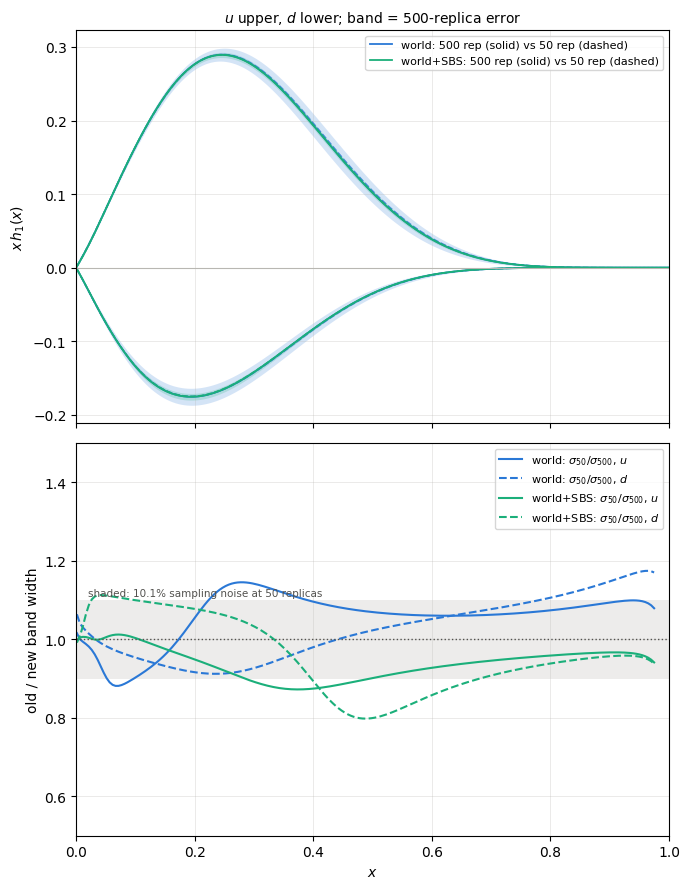

In [4]:
PAIRS = [('world_old', 'world', '#2a78d6', 'world'),
         ('sbs_old',   'sbs',   '#1baf7a', 'world+SBS')]

fig, axes = plt.subplots(2, 1, figsize=(7, 9), sharex=True)

# top: each pair overlaid -- new solid with its band, old dashed
ax = axes[0]
for old, new, color, name in PAIRS:
    for q, E in (('xu', 'Exu'), ('xd', 'Exd')):
        ax.fill_between(X, S[new][q]-S[new][E], S[new][q]+S[new][E],
                        color=color, alpha=0.20, lw=0)
        ax.plot(X, S[new][q], color=color, lw=1.3, ls='-')
        ax.plot(X, S[old][q], color=color, lw=1.1, ls='--', alpha=0.8)
    ax.plot([], [], color=color, lw=1.3, label=f'{name}: 500 rep (solid) vs 50 rep (dashed)')
ax.axhline(0, color='#b8b7b2', lw=0.8)
ax.set_ylabel(r'$x\,h_1(x)$'); ax.set_xlim(0, 1)
ax.legend(fontsize=8); ax.grid(color='#b8b7b2', lw=0.4, alpha=0.5)
ax.set_title(r'$u$ upper, $d$ lower; band = 500-replica error', fontsize=10)

# bottom: old/new band width WITHIN each pair -- no cross-dataset ratio
ax = axes[1]
for old, new, color, name in PAIRS:
    for E, ls, lab in (('Exu', '-', 'u'), ('Exd', '--', 'd')):
        den = S[new][E]
        r = np.where(den > 0, S[old][E] / np.where(den > 0, den, 1), np.nan)
        ax.plot(X, r, color=color, ls=ls, label=rf'{name}: $\sigma_{{50}}/\sigma_{{500}}$, ${lab}$')
ax.axhline(1, color='#52514e', lw=1.0, ls=':')
ax.axhspan(1-0.101, 1+0.101, color='#b8b7b2', alpha=0.25, lw=0)
ax.text(0.02, 1.11, 'shaded: 10.1% sampling noise at 50 replicas', fontsize=7.5, color='#52514e')
ax.set_xlabel('$x$'); ax.set_ylabel('old / new band width')
ax.set_ylim(0.5, 1.5); ax.legend(fontsize=8); ax.grid(color='#b8b7b2', lw=0.4, alpha=0.5)
fig.tight_layout()

## $g_T(u-d)$, truncated to $0.05 < x < 0.6$

The number the projections are quoted through. Central values should agree —
same data, same model — while the errors carry both the vintage difference and
the replica-count difference.

In [5]:
rows = []
for key in fits:
    n = len(fits[key])
    rows.append({'fit': LABEL[key], 'replicas': n,
                 'gT(u-d)': f"{S[key]['gud']:.4f}",
                 'error':   f"{S[key]['Egud']:.4f}",
                 'noise on the error': f"{100/np.sqrt(2*(n-1)):.1f}%"})
print(pd.DataFrame(rows).set_index('fit').to_string())

print('\n--- old vs new, within each dataset ---')
for old, new, name in (('world_old', 'world', 'world'), ('sbs_old', 'sbs', 'world+SBS')):
    dc    = S[old]['gud'] - S[new]['gud']
    sig   = dc / np.hypot(S[old]['Egud'], S[new]['Egud'])
    ratio = S[old]['Egud'] / S[new]['Egud']
    noise = 1/np.sqrt(2*(len(fits[old])-1))
    verdict = 'within sampling noise' if abs(ratio-1) < noise else 'BEYOND sampling noise'
    print(f"  {name:10s} central {dc:+.4f} ({sig:+.2f} sigma)   "
          f"error x{ratio:.3f} vs {100*noise:.1f}% noise -> {verdict}")

                    replicas gT(u-d)   error noise on the error
fit                                                            
world, 500 rep           500  0.7654  0.0242               3.2%
world, 50 rep             50  0.7664  0.0238              10.1%
world+SBS, 500 rep       500  0.7652  0.0077               3.2%
world+SBS, 50 rep         50  0.7646  0.0068              10.1%

--- old vs new, within each dataset ---
  world      central +0.0010 (+0.03 sigma)   error x0.983 vs 10.1% noise -> within sampling noise
  world+SBS  central -0.0006 (-0.05 sigma)   error x0.885 vs 10.1% noise -> BEYOND sampling noise


## What to conclude

One question only: **does the replica count change the answer?**

Central values should sit on top of each other — same data, same model. Errors
should differ by less than the sampling noise on the 50-replica ensemble
(10.1%). Where an error ratio exceeds that, the small ensemble was a lucky or
unlucky draw, and any improvement factor quoted from it inherits that.

Nothing here compares world against world+SBS; those are different datasets and
that comparison belongs in the phicompare notebook.